Saving Solar.csv to Solar.csv
Loaded: Solar.csv | shape: (8760, 8)


,Date-Hour(NMT),WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
0,01.01.2017-00:00,0.6,0,1003.8,-7.4,0.1,97,0.0
1,01.01.2017-01:00,1.7,0,1003.5,-7.4,-0.2,98,0.0
2,01.01.2017-02:00,0.6,0,1003.4,-6.7,-1.2,99,0.0
3,01.01.2017-03:00,2.4,0,1003.3,-7.2,-1.3,99,0.0
4,01.01.2017-04:00,4.0,0,1003.1,-6.3,3.6,67,0.0



X shape: (8760, 10) | y shape: (8760,)
Features: ['WindSpeed', 'Sunshine', 'AirPressure', 'Radiation', 'AirTemperature', 'RelativeAirHumidity', 'Year', 'Month', 'Day', 'Hour']

Train period: 2017-01-01 00:00:00 → 2017-10-19 23:00:00 | rows: 7008
Test  period: 2017-10-20 00:00:00 → 2017-12-31 23:00:00 | rows: 1752
XGBoost: RMSE=291.8778 | MAE=119.9563 | R2=0.1163

Seq train: (6984, 24, 10) | Seq test: (1728, 24, 10)
Epoch 1/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 3810995.7500 - val_loss: 1070418.1250
Epoch 2/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 3725643.0000 - val_loss: 1025768.8125
Epoch 3/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 3605828.0000 - val_loss: 973966.5625
Epoch 4/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 3450265.2500 - val_loss: 936908.0625
Epoch 5/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 3262554.2500 - val_loss: 833291.5625
Epoch 6/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 3046192.2500 - val_loss: 762376.9375
Ep

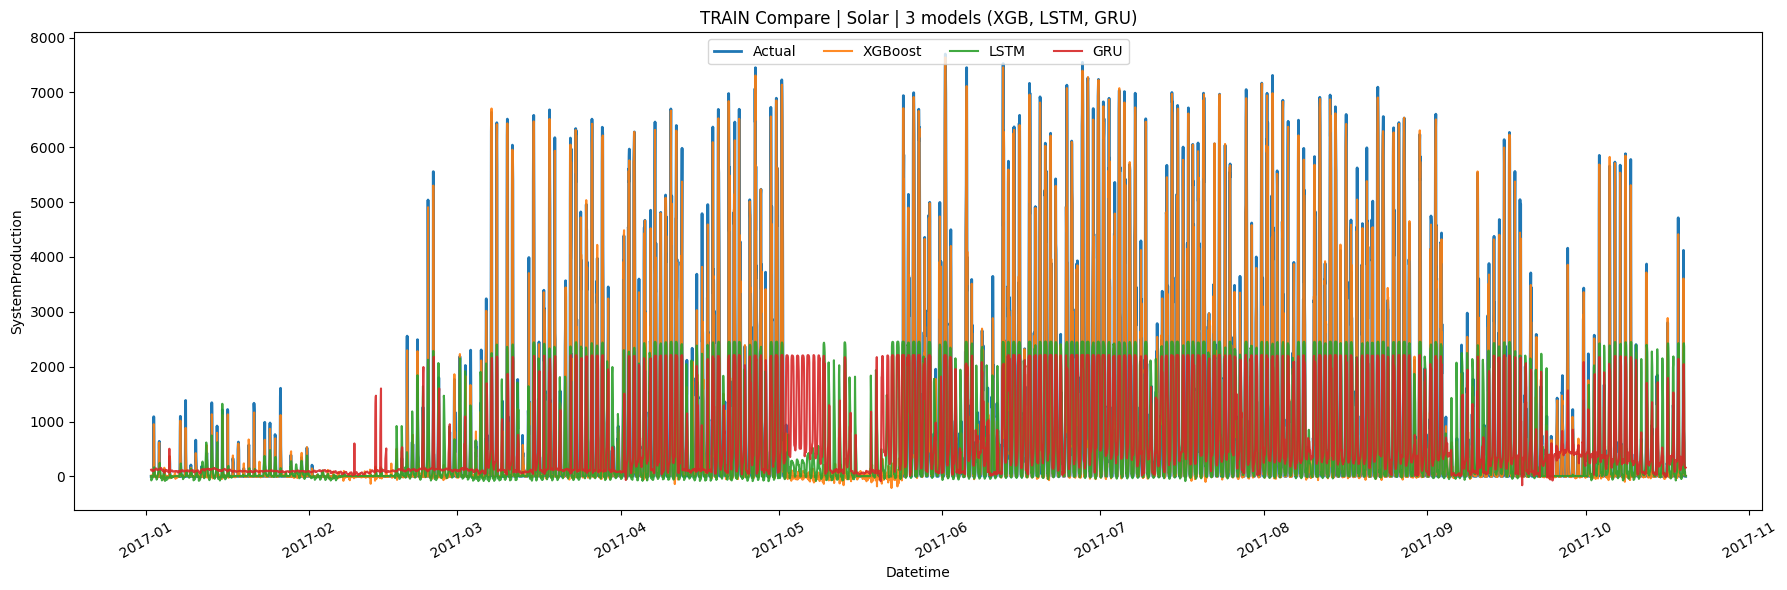

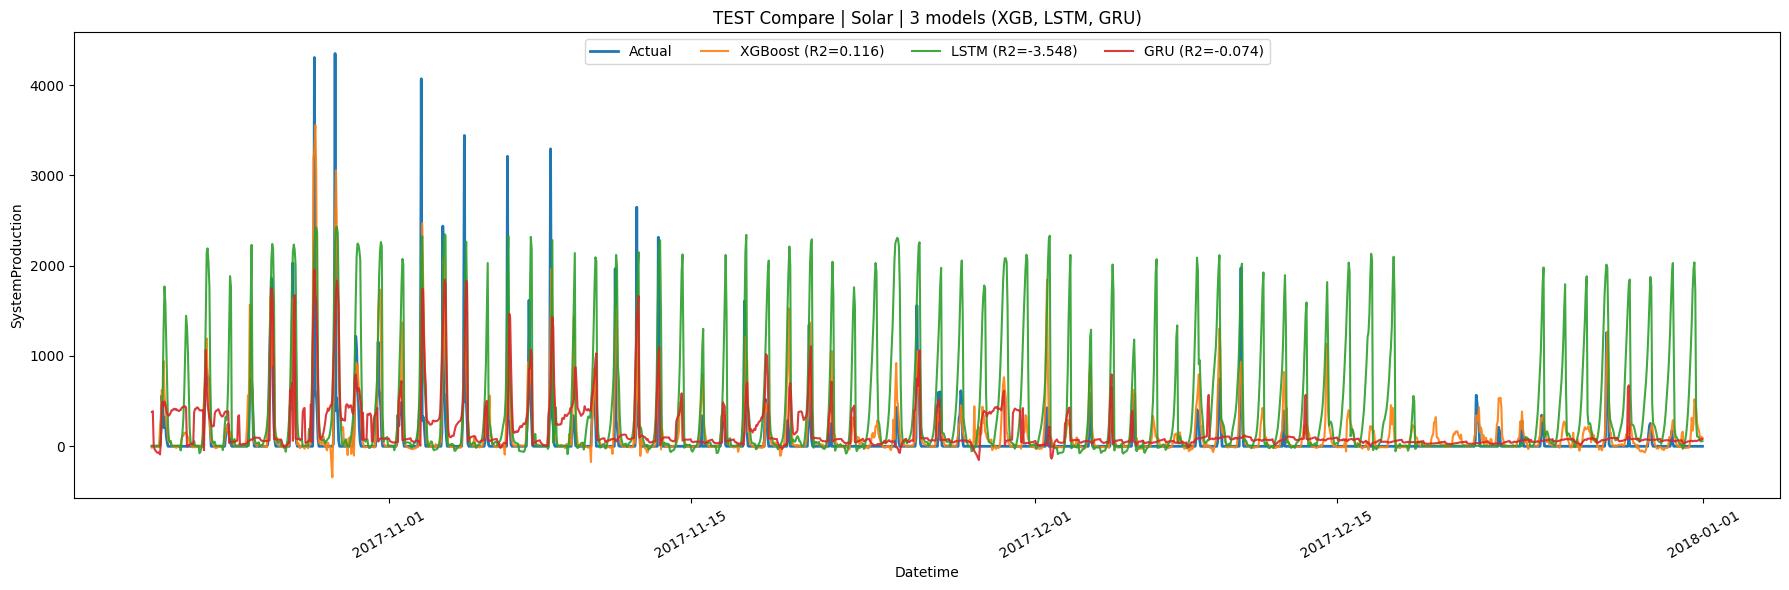

,Model,RMSE,MAE,R2
0,XGBoost,291.877798,119.956308,0.116296
2,GRU,323.210745,171.434906,-0.074227
1,LSTM,665.048731,359.841258,-3.548113



High-error points (top 5%)
XGB : 87 / 1728
LSTM: 87 / 1728
GRU : 87 / 1728

=== SHAP: XGBoost (TreeExplainer) ===


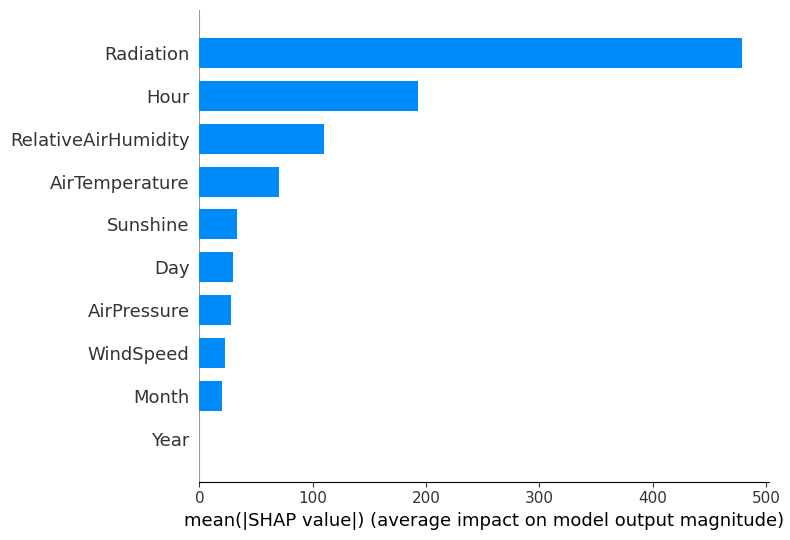

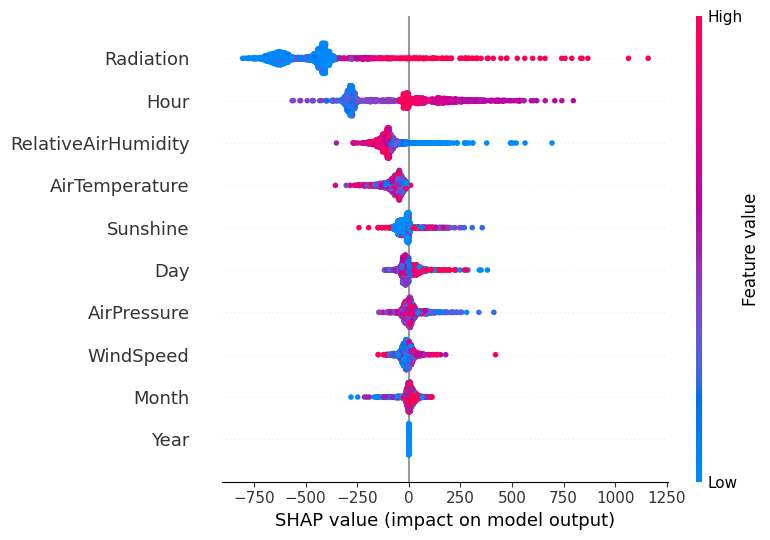

SHAP (XGB) on HIGH-ERROR cases


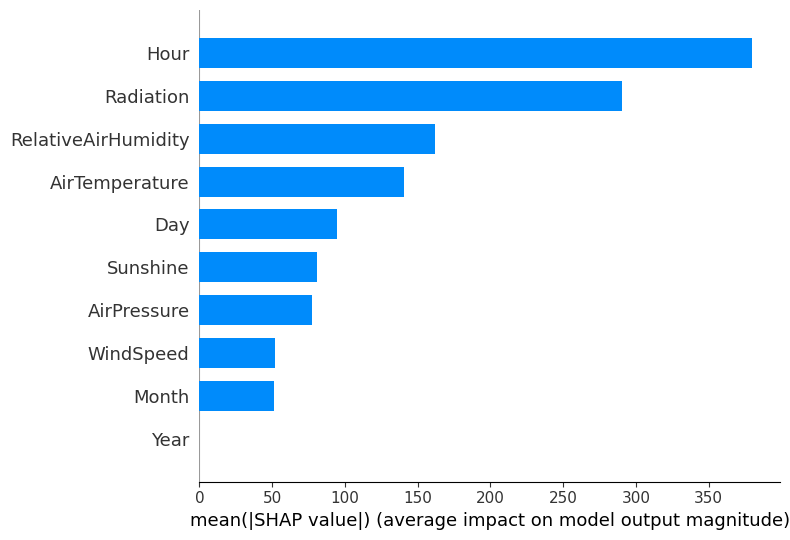


=== SHAP: LSTM & GRU (KernelExplainer, last-step) ===


  0%|          | 0/250 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# FULL COLAB RUNNABLE: XGBoost + LSTM + GRU + SHAP (XAI)
# + TRAIN/TEST Compare plots (Datetime x-axis)
# + Explain HIGH-ERROR cases using SHAP
# ============================================================

# ---------------------------
# 0) Install
# ---------------------------
!pip -q install xgboost shap

# ---------------------------
# 1) Imports
# ---------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras import layers, models

import shap
shap.initjs()

# ---------------------------
# 2) Upload + Load CSV
# ---------------------------
uploaded = files.upload()
csv_name = list(uploaded.keys())[0]
df = pd.read_csv(csv_name)

time_col = "Date-Hour(NMT)"
target   = "SystemProduction"

print("Loaded:", csv_name, "| shape:", df.shape)
display(df.head())

# ---------------------------
# 3) Parse datetime + build time features (Year/Month/Day/Hour)
# ---------------------------
df = df.copy()
df["datetime"] = pd.to_datetime(df[time_col], format="%d.%m.%Y-%H:%M", errors="coerce")
df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

df["Year"]  = df["datetime"].dt.year
df["Month"] = df["datetime"].dt.month
df["Day"]   = df["datetime"].dt.day
df["Hour"]  = df["datetime"].dt.hour

# ---------------------------
# 4) Select features (auto-safe if some missing)
# ---------------------------
base_features = [
    "WindSpeed","Sunshine","AirPressure","Radiation",
    "AirTemperature","RelativeAirHumidity",
    "Year","Month","Day","Hour"
]
feature_cols = [c for c in base_features if c in df.columns]

X_all = df[feature_cols].astype(float)
y_all = df[target].astype(float)
dt_all = df["datetime"].copy()

print("\nX shape:", X_all.shape, "| y shape:", y_all.shape)
print("Features:", feature_cols)

# ---------------------------
# 5) Time-based split 80/20
# ---------------------------
split_idx = int(len(df) * 0.8)

X_train = X_all.iloc[:split_idx].copy()
X_test  = X_all.iloc[split_idx:].copy()
y_train = y_all.iloc[:split_idx].copy()
y_test  = y_all.iloc[split_idx:].copy()

dt_train = dt_all.iloc[:split_idx].reset_index(drop=True)
dt_test  = dt_all.iloc[split_idx:].reset_index(drop=True)

def eval_reg(y_true, y_pred, name="model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name}: RMSE={rmse:.4f} | MAE={mae:.4f} | R2={r2:.4f}")
    return rmse, mae, r2

print("\nTrain period:", dt_train.min(), "→", dt_train.max(), "| rows:", len(dt_train))
print("Test  period:", dt_test.min(),  "→", dt_test.max(),  "| rows:", len(dt_test))

# ============================================================
# 6) MODEL 1: XGBoost
# ============================================================
xgb_model = xgb.XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

pred_xgb_train = xgb_model.predict(X_train)
pred_xgb_test  = xgb_model.predict(X_test)

rmse_xgb, mae_xgb, r2_xgb = eval_reg(y_test, pred_xgb_test, "XGBoost")

# ============================================================
# 7) Prepare sequences for LSTM/GRU
# ============================================================
lookback = 24  # 24 hours

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

y_train_np = y_train.values
y_test_np  = y_test.values

def make_sequences(X_arr, y_arr, lookback):
    X_seq, y_seq = [], []
    for i in range(lookback, len(X_arr)):
        X_seq.append(X_arr[i-lookback:i, :])
        y_seq.append(y_arr[i])
    return np.array(X_seq), np.array(y_seq)

Xtr_seq, ytr_seq = make_sequences(X_train_s, y_train_np, lookback)
Xte_seq, yte_seq = make_sequences(X_test_s,  y_test_np,  lookback)

dt_train_seq = dt_train.iloc[lookback:].reset_index(drop=True)
dt_test_seq  = dt_test.iloc[lookback:].reset_index(drop=True)

n_features = Xtr_seq.shape[-1]
print("\nSeq train:", Xtr_seq.shape, "| Seq test:", Xte_seq.shape)

# ============================================================
# 8) MODEL 2: LSTM
# ============================================================
tf.random.set_seed(42)
lstm = models.Sequential([
    layers.Input(shape=(lookback, n_features)),
    layers.LSTM(64),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])
lstm.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")

hist_lstm = lstm.fit(
    Xtr_seq, ytr_seq,
    epochs=15, batch_size=64,
    validation_split=0.1,
    verbose=1
)

pred_lstm_train = lstm.predict(Xtr_seq, verbose=0).ravel()
pred_lstm_test  = lstm.predict(Xte_seq, verbose=0).ravel()

rmse_lstm, mae_lstm, r2_lstm = eval_reg(yte_seq, pred_lstm_test, "LSTM")

# ============================================================
# 9) MODEL 3: GRU
# ============================================================
tf.random.set_seed(42)
gru = models.Sequential([
    layers.Input(shape=(lookback, n_features)),
    layers.GRU(64),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])
gru.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")

hist_gru = gru.fit(
    Xtr_seq, ytr_seq,
    epochs=15, batch_size=64,
    validation_split=0.1,
    verbose=1
)

pred_gru_train = gru.predict(Xtr_seq, verbose=0).ravel()
pred_gru_test  = gru.predict(Xte_seq, verbose=0).ravel()

rmse_gru, mae_gru, r2_gru = eval_reg(yte_seq, pred_gru_test, "GRU")

# ============================================================
# 10) Build TRAIN/TEST Compare tables (aligned timeline)
# ============================================================
train_compare = pd.DataFrame({
    "Actual": y_train_np[lookback:],
    "XGB":    pred_xgb_train[lookback:],
    "LSTM":   pred_lstm_train,
    "GRU":    pred_gru_train
}, index=dt_train_seq)

test_compare = pd.DataFrame({
    "Actual": y_test_np[lookback:],
    "XGB":    pred_xgb_test[lookback:],
    "LSTM":   pred_lstm_test,
    "GRU":    pred_gru_test
}, index=dt_test_seq)

# ============================================================
# 11) Plot TRAIN Compare (like your example)
# ============================================================
plt.figure(figsize=(18,6))
plt.plot(train_compare.index, train_compare["Actual"], label="Actual", linewidth=2)
plt.plot(train_compare.index, train_compare["XGB"],   label="XGBoost", alpha=0.9)
plt.plot(train_compare.index, train_compare["LSTM"],  label="LSTM", alpha=0.9)
plt.plot(train_compare.index, train_compare["GRU"],   label="GRU", alpha=0.9)
plt.title("TRAIN Compare | Solar | 3 models (XGB, LSTM, GRU)")
plt.xlabel("Datetime")
plt.ylabel("SystemProduction")
plt.xticks(rotation=30)
plt.legend(ncol=4, loc="upper center")
plt.tight_layout()
plt.show()

# ============================================================
# 12) Plot TEST Compare (like your example)
# ============================================================
plt.figure(figsize=(18,6))
plt.plot(test_compare.index, test_compare["Actual"], label="Actual", linewidth=2)
plt.plot(test_compare.index, test_compare["XGB"],   label=f"XGBoost (R2={r2_xgb:.3f})", alpha=0.9)
plt.plot(test_compare.index, test_compare["LSTM"],  label=f"LSTM (R2={r2_lstm:.3f})", alpha=0.9)
plt.plot(test_compare.index, test_compare["GRU"],   label=f"GRU (R2={r2_gru:.3f})", alpha=0.9)
plt.title("TEST Compare | Solar | 3 models (XGB, LSTM, GRU)")
plt.xlabel("Datetime")
plt.ylabel("SystemProduction")
plt.xticks(rotation=30)
plt.legend(ncol=4, loc="upper center")
plt.tight_layout()
plt.show()

# Summary table
summary = pd.DataFrame([
    {"Model":"XGBoost", "RMSE":rmse_xgb, "MAE":mae_xgb, "R2":r2_xgb},
    {"Model":"LSTM",    "RMSE":rmse_lstm,"MAE":mae_lstm,"R2":r2_lstm},
    {"Model":"GRU",     "RMSE":rmse_gru, "MAE":mae_gru, "R2":r2_gru},
]).sort_values("RMSE")
display(summary)

# ============================================================
# 13) ERROR TABLE + HIGH-ERROR POINTS (top 5%)
# ============================================================
test_err = test_compare.copy()
test_err["err_xgb"]  = test_err["Actual"] - test_err["XGB"]
test_err["err_lstm"] = test_err["Actual"] - test_err["LSTM"]
test_err["err_gru"]  = test_err["Actual"] - test_err["GRU"]

test_err["abs_err_xgb"]  = test_err["err_xgb"].abs()
test_err["abs_err_lstm"] = test_err["err_lstm"].abs()
test_err["abs_err_gru"]  = test_err["err_gru"].abs()

q = 0.95
idx_bad_xgb  = test_err["abs_err_xgb"] .ge(test_err["abs_err_xgb"].quantile(q))
idx_bad_lstm = test_err["abs_err_lstm"].ge(test_err["abs_err_lstm"].quantile(q))
idx_bad_gru  = test_err["abs_err_gru"] .ge(test_err["abs_err_gru"].quantile(q))

print("\nHigh-error points (top 5%)")
print("XGB :", idx_bad_xgb.sum(), "/", len(test_err))
print("LSTM:", idx_bad_lstm.sum(), "/", len(test_err))
print("GRU :", idx_bad_gru.sum(), "/", len(test_err))

# ============================================================
# 14) SHAP XAI
# ============================================================

# ---------- 14.1 SHAP for XGBoost (Global + High-error) ----------
print("\n=== SHAP: XGBoost (TreeExplainer) ===")

# Align X_test with test_compare timeline (after lookback)
X_test_align = X_test.iloc[lookback:].copy()
X_test_align.index = dt_test_seq.values  # datetime index same as test_compare

explainer_xgb = shap.TreeExplainer(xgb_model)

# Global sample
Xg = X_test.sample(min(2000, len(X_test)), random_state=42)
shap_xgb = explainer_xgb.shap_values(Xg)
shap.summary_plot(shap_xgb, Xg, plot_type="bar")
shap.summary_plot(shap_xgb, Xg)

# High-error only
X_bad_xgb = X_test_align.loc[test_err.index[idx_bad_xgb]]
if len(X_bad_xgb) > 0:
    X_bad_xgb_s = X_bad_xgb.sample(min(800, len(X_bad_xgb)), random_state=42)
    shap_bad_xgb = explainer_xgb.shap_values(X_bad_xgb_s)
    print("SHAP (XGB) on HIGH-ERROR cases")
    shap.summary_plot(shap_bad_xgb, X_bad_xgb_s, plot_type="bar")

# ---------- 14.2 SHAP for LSTM/GRU (KernelExplainer, last-step) ----------
print("\n=== SHAP: LSTM & GRU (KernelExplainer, last-step) ===")
feature_names = list(X_train.columns)

# last-step features (scaled)
Xte_last = Xte_seq[:, -1, :]

def predict_lstm_last(X_last_2d):
    X_rep = np.repeat(X_last_2d[:, None, :], repeats=lookback, axis=1)
    return lstm.predict(X_rep, verbose=0).ravel()

def predict_gru_last(X_last_2d):
    X_rep = np.repeat(X_last_2d[:, None, :], repeats=lookback, axis=1)
    return gru.predict(X_rep, verbose=0).ravel()

rng = np.random.default_rng(42)
bg_idx = rng.choice(len(Xte_last), size=min(200, len(Xte_last)), replace=False)
bg = Xte_last[bg_idx]

# Global explain (limit for speed)
X_explain = Xte_last[:min(250, len(Xte_last))]

expl_lstm = shap.KernelExplainer(predict_lstm_last, bg)
shap_lstm = expl_lstm.shap_values(X_explain, nsamples=200)
shap.summary_plot(shap_lstm, X_explain, feature_names=feature_names, plot_type="bar")

expl_gru = shap.KernelExplainer(predict_gru_last, bg)
shap_gru = expl_gru.shap_values(X_explain, nsamples=200)
shap.summary_plot(shap_gru, X_explain, feature_names=feature_names, plot_type="bar")

# High-error for LSTM/GRU (map datetime -> sequence position)
dt_seq_index = pd.Index(dt_test_seq.values)
pos_map = pd.Series(np.arange(len(dt_seq_index)), index=dt_seq_index)

bad_pos_lstm = pos_map.loc[test_err.index[idx_bad_lstm]].values if idx_bad_lstm.any() else np.array([], dtype=int)
bad_pos_gru  = pos_map.loc[test_err.index[idx_bad_gru]].values  if idx_bad_gru.any()  else np.array([], dtype=int)

if len(bad_pos_lstm) > 0:
    X_bad_lstm = Xte_last[bad_pos_lstm][:min(200, len(bad_pos_lstm))]
    shap_bad_lstm = expl_lstm.shap_values(X_bad_lstm, nsamples=200)
    print("SHAP (LSTM) on HIGH-ERROR cases")
    shap.summary_plot(shap_bad_lstm, X_bad_lstm, feature_names=feature_names, plot_type="bar")

if len(bad_pos_gru) > 0:
    X_bad_gru = Xte_last[bad_pos_gru][:min(200, len(bad_pos_gru))]
    shap_bad_gru = expl_gru.shap_values(X_bad_gru, nsamples=200)
    print("SHAP (GRU) on HIGH-ERROR cases")
    shap.summary_plot(shap_bad_gru, X_bad_gru, feature_names=feature_names, plot_type="bar")

# ============================================================
# 15) Error vs Feature scatter (Explain "when error increases")
# ============================================================
print("\n=== Error vs Feature (Absolute Error) ===")
merged = X_test_align.join(test_err[["abs_err_xgb","abs_err_lstm","abs_err_gru"]], how="inner")

def error_scatter(feature):
    plt.figure(figsize=(7,5))
    plt.scatter(merged[feature], merged["abs_err_xgb"],  s=10, alpha=0.3, label="XGB")
    plt.scatter(merged[feature], merged["abs_err_lstm"], s=10, alpha=0.3, label="LSTM")
    plt.scatter(merged[feature], merged["abs_err_gru"],  s=10, alpha=0.3, label="GRU")
    plt.xlabel(feature)
    plt.ylabel("Absolute Error")
    plt.title(f"Absolute Error vs {feature}")
    plt.legend()
    plt.tight_layout()
    plt.show()

for f in ["Radiation","AirTemperature","WindSpeed","RelativeAirHumidity","Sunshine"]:
    if f in merged.columns:
        error_scatter(f)

print("\nDONE ✅")
